# 01 -- Global Trade

## Research Question
What does the global trade network actually look like, and who are the real hubs -- by network structure, not just raw trade volume?

## Data
UN Comtrade bilateral total trade, 59 major economies, 2023 (`data/raw/comtrade_bilateral_trade_raw.csv`). PUBLIC.

## Method
Directed graph (NetworkX): edge A-\>B = A's exports to B. Node size = total exports. See `python/networks/trade_network.py` for the full centrality methodology.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display
import sys, os
sys.path.insert(0, os.path.abspath('../python/visualisation'))
pd.set_option('display.max_columns', 20)

In [2]:
comtrade = pd.read_csv('../data/raw/comtrade_bilateral_trade_raw.csv')
countries = pd.read_csv('../data/external/network_countries.csv')
sub2023 = comtrade[(comtrade['period'].astype(str) == '2023') & (comtrade['flow'] == 'X')]
print(f"2023 export network: {sub2023['reporterCode'].nunique()} reporters, {len(sub2023)} bilateral edges")
top_exporters = sub2023.groupby('reporterCode')['primaryValue'].sum().sort_values(ascending=False).head(10)
code_to_name = dict(zip(countries['comtradeReporterCode'], countries['Country']))
top_exporters.index = top_exporters.index.map(code_to_name)
print("\nTop 10 exporters within the 59-country network (2023, USD):")
print(top_exporters.apply(lambda x: f"${x/1e9:.0f}B"))

2023 export network: 50 reporters, 2563 bilateral edges

Top 10 exporters within the 59-country network (2023, USD):
reporterCode
China                   $2297B
Germany                 $1029B
Hong Kong SAR, China     $485B
Japan                    $473B
Netherlands              $449B
France                   $445B
Italy                    $431B
Korea, Rep.              $421B
Singapore                $355B
United Kingdom           $315B
Name: primaryValue, dtype: str


## Analysis

The global trade network chart below (Visualisation 2) shows the same data as a network: node size is total exports, edge lines show bilateral trade relationships. Restricted to the top 25 of 59 economies by export volume (a stated reduction, not a hidden one, corrected after external review found the original all-59-node version produced an unreadable, misleading layout: force-directed layout on a 75%-dense graph with wildly uneven country connectivity flings sparsely-connected countries to arbitrary extreme positions, a layout artifact, not a real finding). The full, unrestricted 59-country network is what the rigorous centrality analysis (betweenness, eigenvector, PageRank) in Notebook 06 is actually computed on; this chart is illustrative.

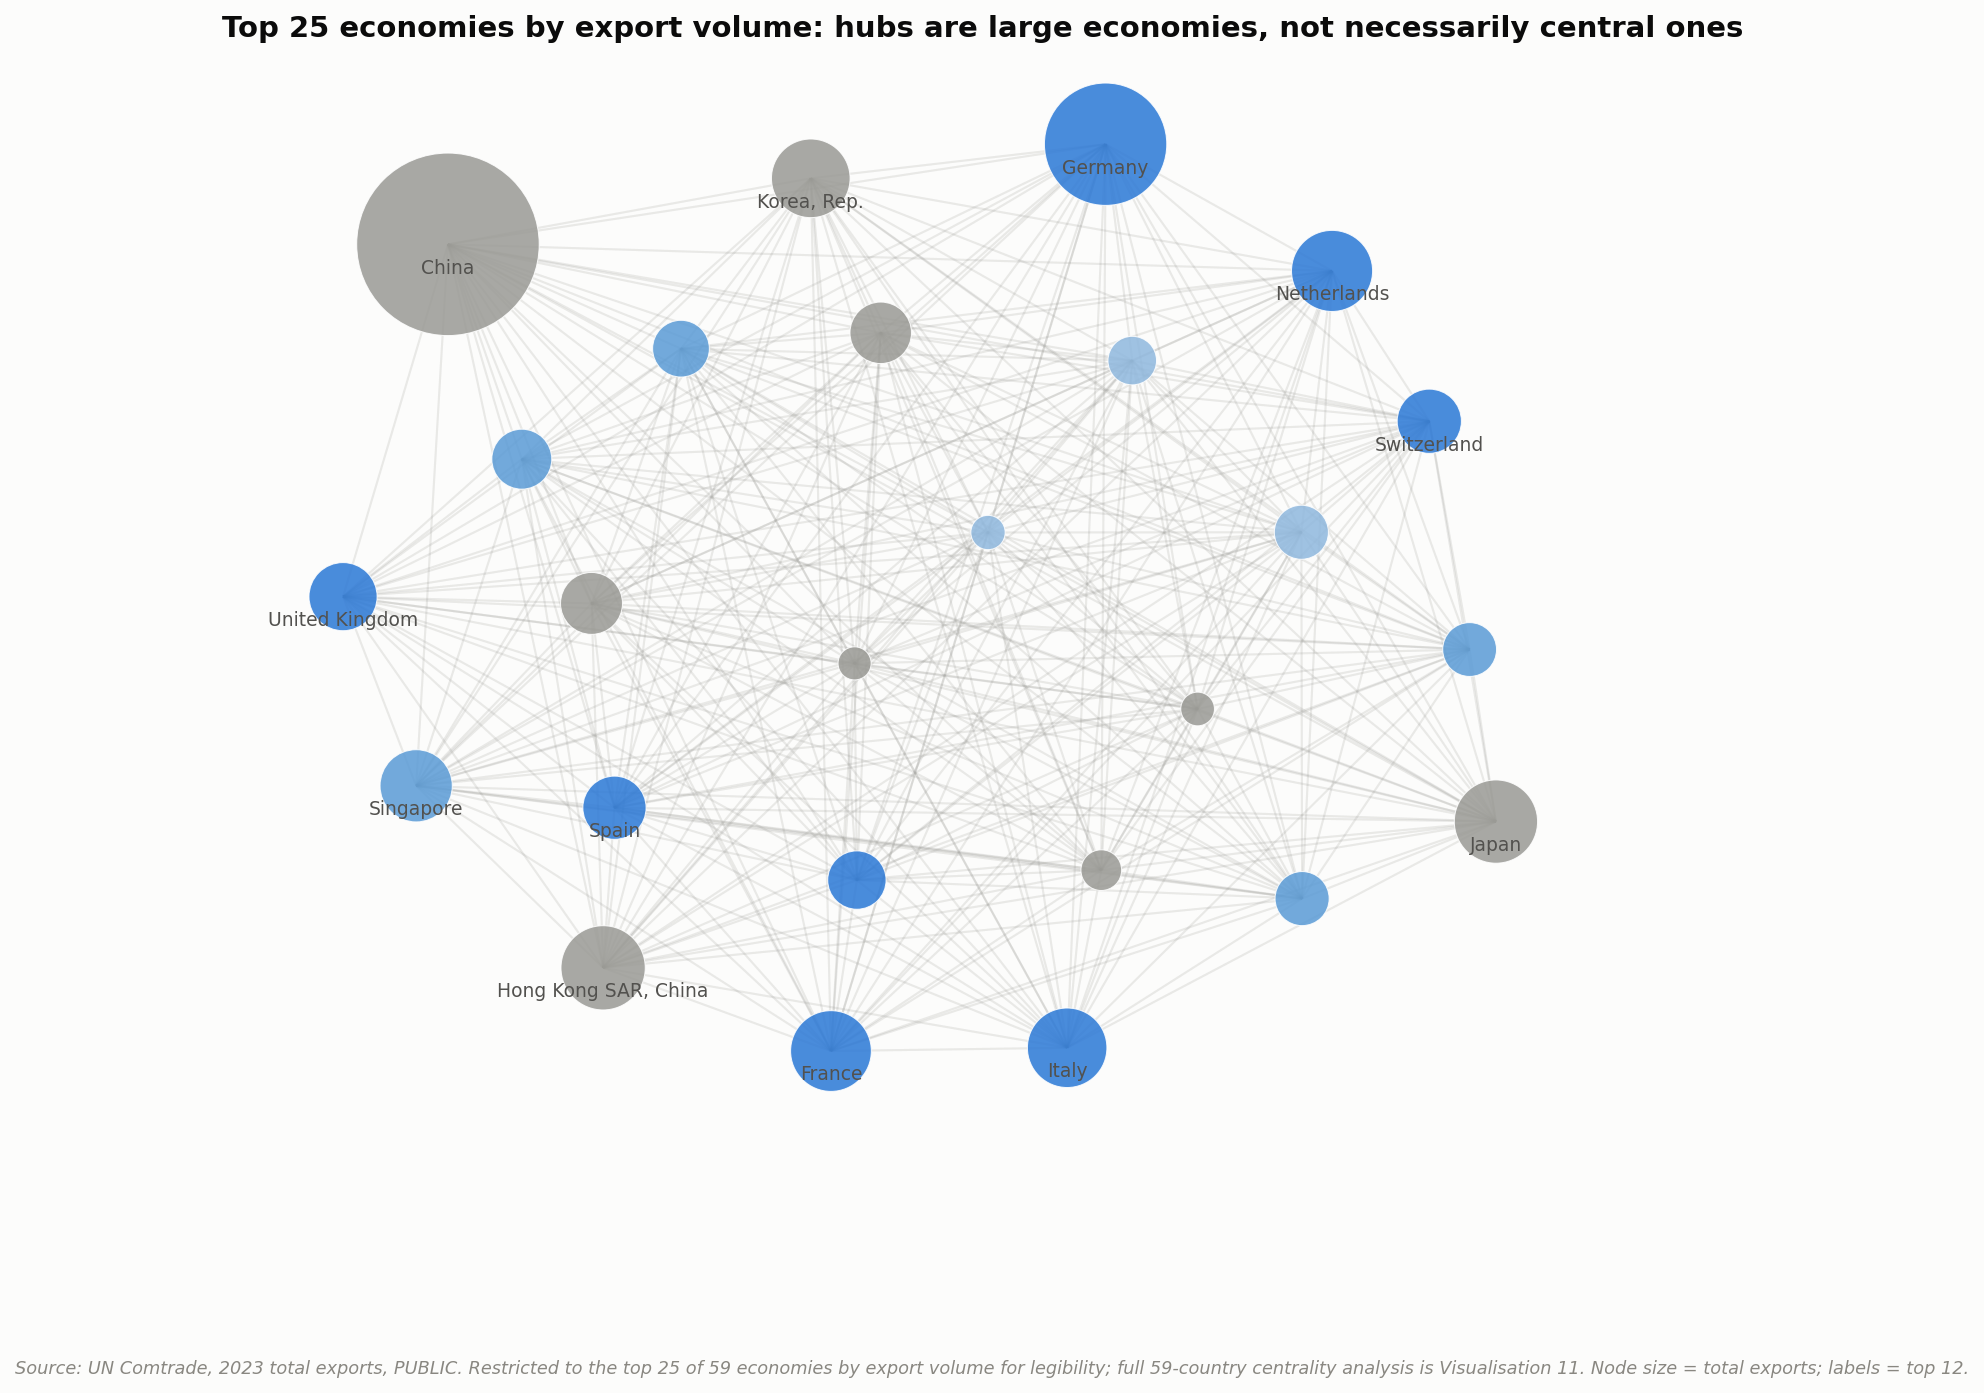

In [3]:
display(Image('../outputs/figures/02_global_trade_network.png', width=800))

## Finding

The biggest exporters by raw value (China, Germany, Netherlands, etc.) are also the most network-central by construction -- but Notebook 06 (Network Analysis) shows this stops being true once betweenness and eigenvector centrality are computed properly, and reveals real divergences (e.g. the UAE's centrality rising far faster than its raw export rank would suggest).

## Limitation

The United States and India are absent from this network entirely -- a genuine free-tier UN Comtrade restriction, not a data quality issue with this project's pipeline. See `docs/LIMITATIONS.md` item 1.

## Next Step

Notebook 02 looks at how this network's structure has changed since 2016.